----------
# **Live Demonstration of Artifact**
- **Inference time**
- **Optimised Grad_CAM explanation time**

-----------

*NB: Calculated under simulated environment*

### **EfficientNetB4**

#### **System Configuration & Environment Setup**

In [8]:
import os
import time
import psutil
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

# Display current system specifications
cpu_freq = psutil.cpu_freq().current
cpu_cores_phys = psutil.cpu_count(logical=False)
cpu_cores_log = psutil.cpu_count(logical=True)
total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
print("=== Current System Specifications ===")
print(f"CPU: {cpu_freq:.0f} MHz, {cpu_cores_phys}p/{cpu_cores_log}l cores")
print(f"Total RAM: {total_ram_gb:.2f} GB")

# Configure Colab to mimic Raspberry Pi 4 environment
PI_CORES = 4        # Quad-core ARM Cortex-A72
PI_CPU_GHZ = 1.5    # 1.5GHz clock speed

print("\n=== Configuring Colab to mimic Raspberry Pi 4 ===")
print(f"Target: {PI_CORES} cores, {PI_CPU_GHZ}GHz clock speed")

# Set TensorFlow thread limitations
os.environ['TF_NUM_INTRAOP_THREADS'] = str(PI_CORES)
os.environ['TF_NUM_INTEROP_THREADS'] = '1'

# Calculate clock speed adjustment factor
try:
    current_ghz = psutil.cpu_freq().current / 1000
    clock_factor = current_ghz / PI_CPU_GHZ
    print(f"Clock speed adjustment factor: {clock_factor:.2f}x")
except:
    clock_factor = 1.5
    print("Using default clock speed factor: 1.50x")

print("Environment configured successfully!")

=== Current System Specifications ===
CPU: 2200 MHz, 1p/2l cores
Total RAM: 12.67 GB

=== Configuring Colab to mimic Raspberry Pi 4 ===
Target: 4 cores, 1.5GHz clock speed
Clock speed adjustment factor: 1.47x
Environment configured successfully!


#### **OptimisedClinicalGradCAM Class Definition**

In [10]:
class OptimisedClinicalGradCAM:
    """
    Minimal, focused Grad-CAM helper for clinical X-ray analysis:
     - Loads H5 model for Grad-CAM computation and classification
     - Compiles optimised tf.function Grad-CAM path with downsampling
     - Provides efficient explanation generation for deployment scenarios
    """

    def __init__(self, h5_path, gradcam_size=(128, 128), target_size=(224, 224), clock_factor=1.0):
        self.clock_factor = clock_factor
        self.h5_model = load_model(h5_path)
        self.target_size = target_size
        self.gradcam_size = gradcam_size

        # Identify last convolutional layer for gradient computation
        self.last_conv_layer = self._find_last_conv_layer()
        self.grad_model = Model(
            inputs=self.h5_model.inputs,
            outputs=[self.h5_model.get_layer(self.last_conv_layer).output, self.h5_model.output]
        )

        # Determine model output type for proper score extraction
        out_shape = self.h5_model.output_shape
        self.model_type = "softmax" if len(out_shape) == 2 and out_shape[1] == 2 else "sigmoid"

        # Compile optimised gradcam function
        self._compile_gradcam_function()

    def _find_last_conv_layer(self):
        for layer in reversed(self.h5_model.layers):
            if 'conv' in layer.name.lower() and len(layer.output.shape) == 4:
                return layer.name
        raise ValueError("No suitable convolutional layer found for Grad-CAM")

    def _compile_gradcam_function(self):
        """Compile efficient Grad-CAM routine with tf.function optimisation."""
        @tf.function
        def _gradcam_compiled(input_tensor):
            with tf.GradientTape() as tape:
                tape.watch(input_tensor)
                conv_output, preds = self.grad_model(input_tensor)
                if self.model_type == "softmax":
                    score = preds[:, 1]    # pneumonia class
                else:
                    score = preds[:, 0]

            grads = tape.gradient(score, conv_output)
            pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
            conv_output = conv_output[0]
            heatmap = tf.tensordot(conv_output, pooled_grads, axes=[[2], [0]])
            heatmap = tf.nn.relu(heatmap)
            heatmap = tf.image.resize(heatmap[..., tf.newaxis], self.target_size)[..., 0]
            return heatmap, preds

        self._gradcam_compiled = _gradcam_compiled

        # Warm-up compilation
        try:
            dummy = tf.zeros((1, *self.gradcam_size, 3), dtype=tf.float32)
            _ = self._gradcam_compiled(dummy)
        except Exception:
            dummy = tf.zeros((1, *self.target_size, 3), dtype=tf.float32)
            _ = self._gradcam_compiled(dummy)

    def prepare_image(self, img_path):
        img = Image.open(img_path).convert('RGB').resize(self.target_size)
        img_arr = np.array(img, dtype=np.float32)
        img_pre = preprocess_input(img_arr.copy())
        img_keras = np.expand_dims(img_pre, 0).astype(np.float32)
        img_display = np.array(img, dtype=np.uint8)
        return img_keras, img_display

    def generate_optimised_gradcam(self, img_keras):
        """Generate Grad-CAM using downsampled input for efficiency."""
        img_small = tf.image.resize(img_keras, self.gradcam_size, method='bilinear')
        start = time.perf_counter()
        try:
            heatmap_tf, preds = self._gradcam_compiled(img_small)
        except Exception:
            heatmap_tf, preds = self._gradcam_compiled(img_keras)
        elapsed = (time.perf_counter() - start) * self.clock_factor

        heatmap = heatmap_tf.numpy()

        # Normalise heatmap values
        if heatmap.max() > 0:
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        else:
            heatmap = np.zeros_like(heatmap)
        return heatmap, preds[0], elapsed

    def create_overlay(self, original_img, heatmap, alpha=0.4):
        gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
        gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        heatmap_colored = cv2.applyColorMap((heatmap * 255).astype('uint8'), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(heatmap_colored, alpha, gray_rgb, 1 - alpha, 0)
        return overlay

print("OptimisedClinicalGradCAM class loaded successfully!")

OptimisedClinicalGradCAM class loaded successfully!


#### **TFLite Model Inference Time (Single Image)**

In [23]:
# Load quantised TFLite model for efficient inference
quantized_model_path = '/content/drive/MyDrive/NIH_models/Quantized/EffNetB4_quantized_hybrid.tflite'
interpreter = tf.lite.Interpreter(quantized_model_path)
input_details = interpreter.get_input_details()

# Configure input tensor shape
interpreter.resize_tensor_input(input_details[0]['index'], [1, 224, 224, 3])
interpreter.allocate_tensors()
output_details = interpreter.get_output_details()

def prepare_image_tflite(path):
    """Preprocess image for TFLite inference."""
    img = Image.open(path).convert('RGB').resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_array = preprocess_input(img_array)
    return np.expand_dims(img_array, axis=0)

# Load test image
test_img_path = '/content/drive/MyDrive/NIH_ChestXray/NIH_Processed/test/pneumonia/00012747_006.png'
input_data = prepare_image_tflite(test_img_path)

# Warm-up inference to ensure stable timing
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Measure actual inference time
start_time = time.perf_counter()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
inference_duration_ms = (time.perf_counter() - start_time) * 1000 * clock_factor

# Get model predictions
output_data = interpreter.get_tensor(output_details[0]['index'])

# Display results
model_size_mb = os.path.getsize(quantized_model_path) / (1024*1024)
print("=== TFLite Inference Results ===")
print(f"Model: {os.path.basename(quantized_model_path)}")
print(f"Model size: {model_size_mb:.2f} MB")
print(f"Simulated Pi4 inference time: {inference_duration_ms:.2f} ms")
print(f"Prediction output: {float(output_data[0]):.4f}")

=== TFLite Inference Results ===
Model: EffNetB4_quantized_hybrid.tflite
Model size: 18.59 MB
Simulated Pi4 inference time: 178.78 ms
Prediction output: 0.9997


/tmp/ipython-input-1801739597.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Prediction output: {float(output_data[0]):.4f}")


#### **Optimised Grad-CAM Explanation Generation**

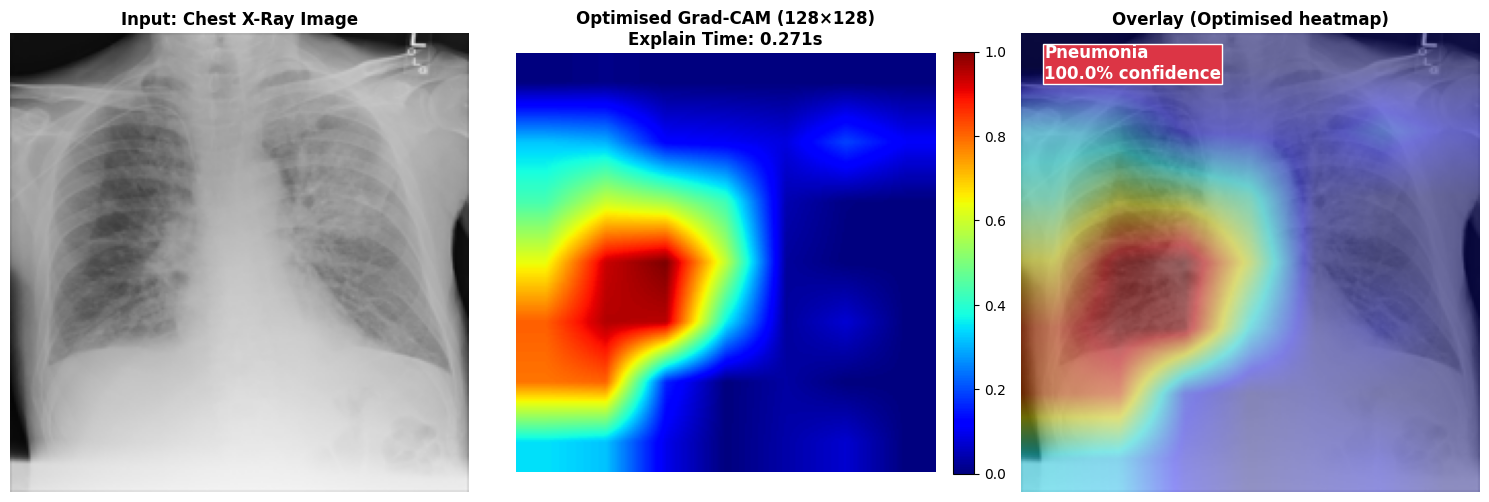


=== Complete Pipeline Performance Summary ===
TFLite inference time: 178.78 ms
Optimized Grad-CAM time: 271.19 ms
Total explanation pipeline: 449.98 ms
Model size: 18.59 MB
Final diagnosis: Pneumonia (100.0% confidence)


In [26]:
# Initialise Grad-CAM with the full model
H5_MODEL_PATH = '/content/drive/MyDrive/NIH_models/Results/EffNetB4_epoch_15.h5'
gradcam = OptimisedClinicalGradCAM(
    h5_path=H5_MODEL_PATH,
    gradcam_size=(128, 128),
    target_size=(224, 224),
    clock_factor=clock_factor
)

# Prepare image for Grad-CAM analysis
img_keras, img_display = gradcam.prepare_image(test_img_path)

# Generate optimized Grad-CAM explanation
heat_opt, preds_opt, gradcam_time = gradcam.generate_optimised_gradcam(img_keras)

# Extract diagnosis and confidence
if gradcam.model_type == "softmax":
    # Two-class output [normal, pneumonia]
    softmax_probs = tf.nn.softmax(tf.expand_dims(preds_opt, 0))[0]
    norm_prob = float(softmax_probs[0])
    pneu_prob = float(softmax_probs[1])
else:
    # Single sigmoid output
    pneu_prob = float(preds_opt)
    norm_prob = 1.0 - pneu_prob

diagnosis = "Pneumonia" if pneu_prob > 0.5 else "Normal"
confidence = (pneu_prob if diagnosis == "Pneumonia" else norm_prob) * 100.0

### Create overlay visualization
overlay = gradcam.create_overlay(img_display, heat_opt)

# Create comprehensive visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Original X-ray
axes[0].imshow(img_display, cmap='gray')
axes[0].set_title("Input: Chest X-Ray Image", fontweight='bold')
axes[0].axis('off')

# Panel 2: Grad-CAM heatmap with timing info
ax1 = axes[1].imshow(heat_opt, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Optimised Grad-CAM (128×128)\nExplain Time: {gradcam_time:.3f}s", fontweight='bold')
axes[1].axis('off')
plt.colorbar(ax1, ax=axes[1], fraction=0.046, pad=0.04)

# Panel 3: Overlay with diagnosis
axes[2].imshow(overlay)
axes[2].set_title("Overlay (Optimised heatmap)", fontweight='bold')
axes[2].axis('off')

# Add diagnosis annotation
text_color = '#dc3545' if diagnosis == "Pneumonia" else '#28a745'
axes[2].text(0.05, 0.90, f"{diagnosis}\n{confidence:.1f}% confidence",
             transform=axes[2].transAxes, color='white', fontsize=12, fontweight='bold',
             bbox=dict(facecolor=text_color, edgecolor='white', pad=0.5))

plt.tight_layout()
plt.show()

# Final performance summary
print("\n=== Complete Pipeline Performance Summary ===")
print(f"TFLite inference time: {inference_duration_ms:.2f} ms")
print(f"Optimized Grad-CAM time: {gradcam_time*1000:.2f} ms")
print(f"Total explanation pipeline: {inference_duration_ms + gradcam_time*1000:.2f} ms")
print(f"Model size: {model_size_mb:.2f} MB")
print(f"Final diagnosis: {diagnosis} ({confidence:.1f}% confidence)")

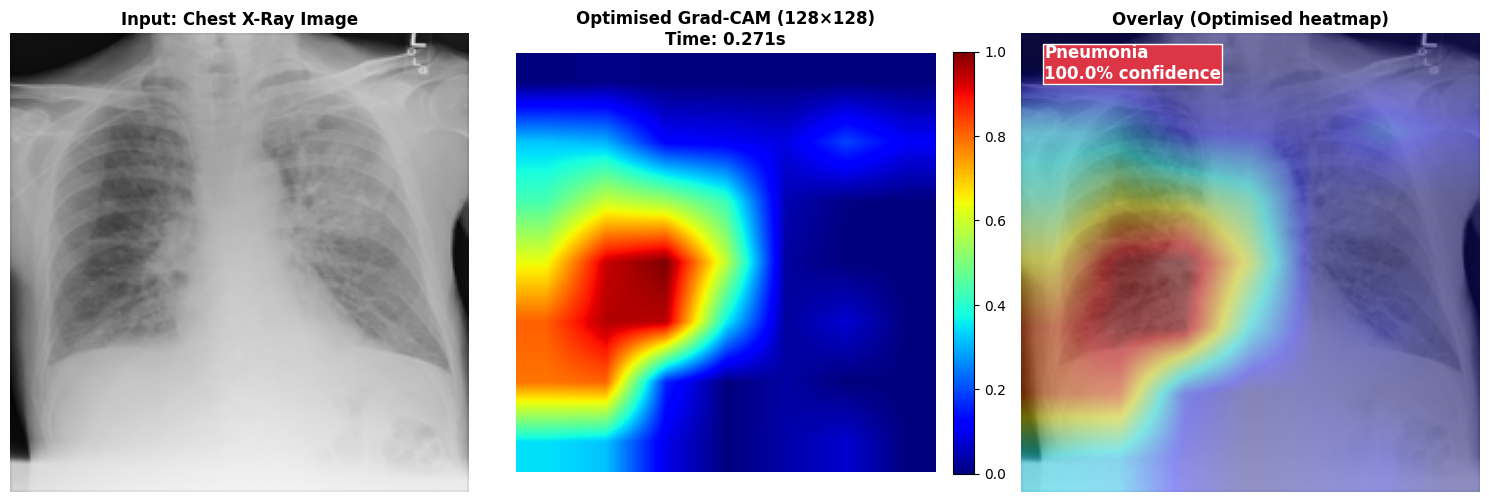


=== Complete Pipeline Performance Summary ===
TFLite inference time: 178.78 ms
Optimized Grad-CAM time: 271.19 ms
Total explanation pipeline: 449.98 ms
Model size: 18.59 MB
Final diagnosis: Pneumonia (100.0% confidence)


In [31]:
# Create overlay visualization
overlay = gradcam.create_overlay(img_display, heat_opt)

# Create comprehensive visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Original X-ray
axes[0].imshow(img_display, cmap='gray')
axes[0].set_title("Input: Chest X-Ray Image", fontweight='bold')
axes[0].axis('off')

# Panel 2: Grad-CAM heatmap with timing info
ax1 = axes[1].imshow(heat_opt, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Optimised Grad-CAM (128×128)\nTime: {gradcam_time:.3f}s", fontweight='bold')
axes[1].axis('off')
plt.colorbar(ax1, ax=axes[1], fraction=0.046, pad=0.04)

# Panel 3: Overlay with diagnosis
axes[2].imshow(overlay)
axes[2].set_title("Overlay (Optimised heatmap)", fontweight='bold')
axes[2].axis('off')

# Add diagnosis annotation
text_color = '#dc3545' if diagnosis == "Pneumonia" else '#28a745'
axes[2].text(0.05, 0.90, f"{diagnosis}\n{confidence:.1f}% confidence",
             transform=axes[2].transAxes, color='white', fontsize=12, fontweight='bold',
             bbox=dict(facecolor=text_color, edgecolor='white', pad=0.5))

plt.tight_layout()
plt.show()

# Final performance summary
print("\n=== Complete Pipeline Performance Summary ===")
print(f"TFLite inference time: {inference_duration_ms:.2f} ms")
print(f"Optimized Grad-CAM time: {gradcam_time*1000:.2f} ms")
print(f"Total explanation pipeline: {inference_duration_ms + gradcam_time*1000:.2f} ms")
print(f"Model size: {model_size_mb:.2f} MB")
print(f"Final diagnosis: {diagnosis} ({confidence:.1f}% confidence)")

#### **Visualisation & Combined Results (Inference & Optimised Grad-CAM Explanation Time)**

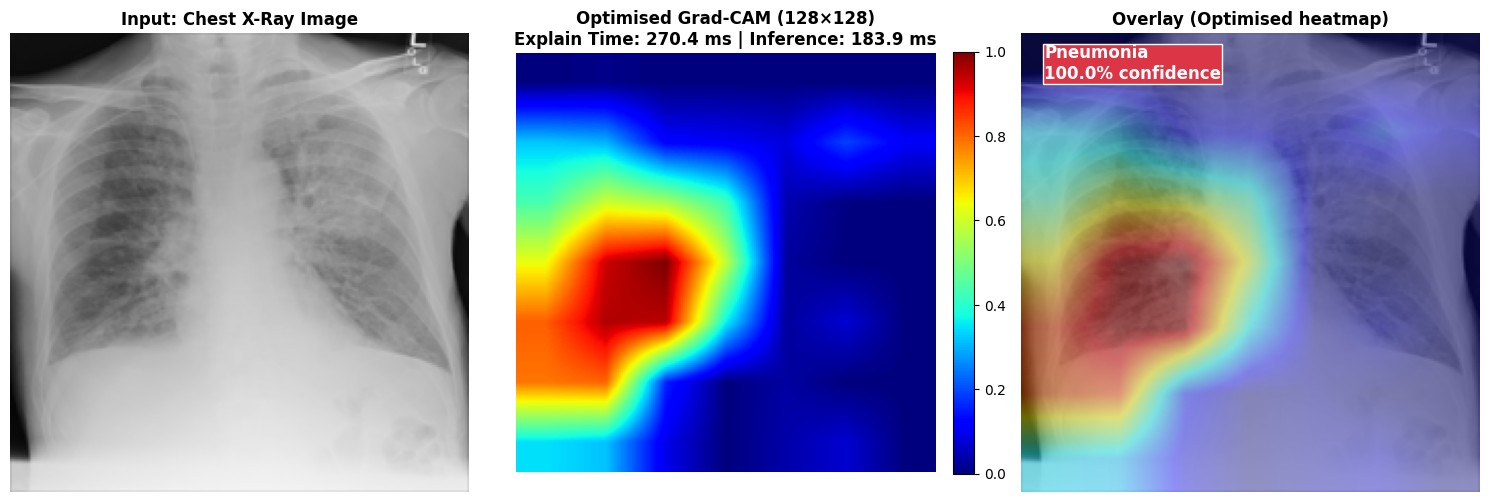

Inference time: 183.94 ms
Optimised Grad-CAM time: 270.44 ms


In [41]:
# Load TFLite quantized model
quantized_model_path = '/content/drive/MyDrive/NIH_models/Quantized/EffNetB4_quantized_hybrid.tflite'
interpreter = tf.lite.Interpreter(quantized_model_path)
input_details = interpreter.get_input_details()
interpreter.resize_tensor_input(input_details[0]['index'], [1, 224, 224, 3])
interpreter.allocate_tensors()

# Preprocessing for EfficientNet
def prepare_image_tflite(path):
    img = Image.open(path).convert('RGB').resize((224,224))
    arr = np.array(img, dtype=np.float32)
    arr = preprocess_input(arr.copy())
    return np.expand_dims(arr, 0)

# Load and preprocess the test image
test_img_path = '/content/drive/MyDrive/NIH_ChestXray/NIH_Processed/test/pneumonia/00012747_006.png'
input_data = prepare_image_tflite(test_img_path)

# Warm-up run
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Measure inference time
start = time.perf_counter()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
duration_ms = (time.perf_counter() - start) * 1000 * clock_factor

# Generate Optimised Grad-CAM (reuse the gradcam object from Task 2)
img_keras, img_display = gradcam.prepare_image(test_img_path)
heat_opt, preds_opt, t_opt = gradcam.generate_optimised_gradcam(img_keras)

# Determine diagnosis and confidence (same logic as above)
if gradcam.model_type == "softmax":
    norm_prob = float(tf.nn.softmax(tf.expand_dims(preds_opt,0))[0,0])
    pneu_prob = float(tf.nn.softmax(tf.expand_dims(preds_opt,0))[0,1])
else:
    pneu_prob = float(preds_opt)
    norm_prob = 1.0 - pneu_prob
diagnosis = "Pneumonia" if pneu_prob > 0.5 else "Normal"
confidence = (pneu_prob if diagnosis=="Pneumonia" else norm_prob) * 100.0
overlay = gradcam.create_overlay(img_display, heat_opt)

# Plot 3 panels as before
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_display, cmap='gray')
axes[0].set_title("Input: Chest X-Ray Image", fontweight='bold')
axes[0].axis('off')

ax1 = axes[1].imshow(heat_opt, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Optimised Grad-CAM (128×128)\nExplain Time: {t_opt*1000:.1f} ms | Inference: {duration_ms:.1f} ms", fontweight='bold')
axes[1].axis('off')
plt.colorbar(ax1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(overlay)
axes[2].set_title("Overlay (Optimised heatmap)", fontweight='bold')
axes[2].axis('off')
axes[2].text(0.05, 0.90, f"{diagnosis}\n{confidence:.1f}% confidence",
             transform=axes[2].transAxes, color='white', fontsize=12, fontweight='bold',
             bbox=dict(facecolor=text_color, edgecolor='white', pad=0.5))
plt.tight_layout()
plt.show()

# Print timing results
print(f"Inference time: {duration_ms:.2f} ms")
print(f"Optimised Grad-CAM time: {t_opt*1000:.2f} ms")

#### **Testing other images (Normal)**

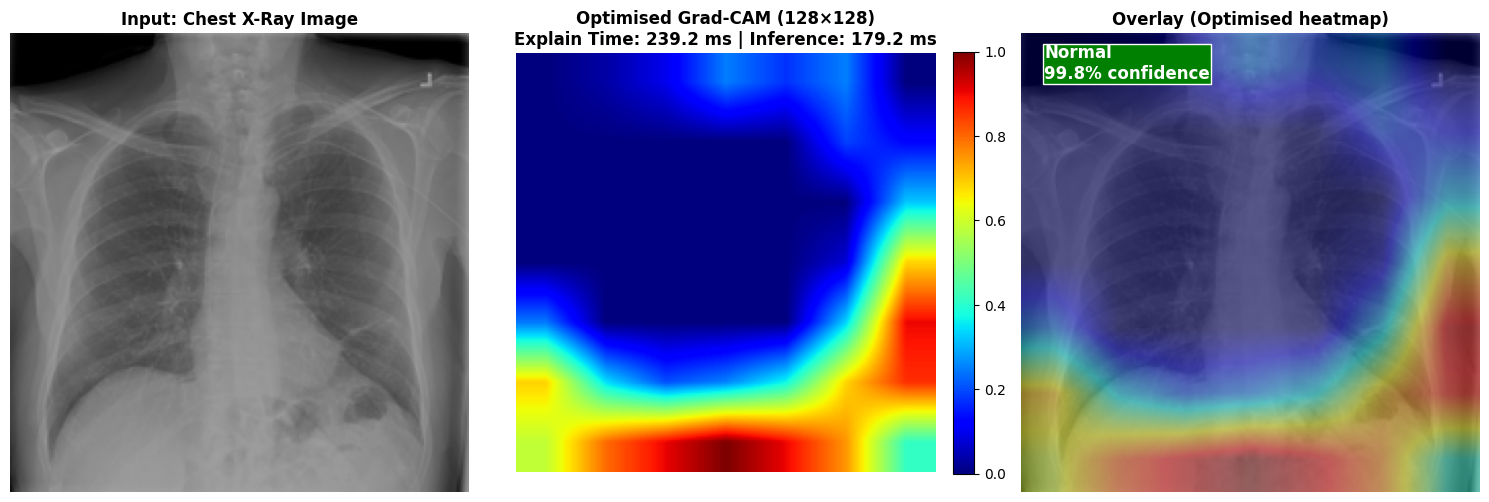

Inference time: 179.17 ms
Optimised Grad-CAM time: 239.18 ms


In [43]:
# Load TFLite quantized model
quantized_model_path = '/content/drive/MyDrive/NIH_models/Quantized/EffNetB4_quantized_hybrid.tflite'
interpreter = tf.lite.Interpreter(quantized_model_path)
input_details = interpreter.get_input_details()
interpreter.resize_tensor_input(input_details[0]['index'], [1, 224, 224, 3])
interpreter.allocate_tensors()

# Preprocessing for EfficientNet
def prepare_image_tflite(path):
    img = Image.open(path).convert('RGB').resize((224,224))
    arr = np.array(img, dtype=np.float32)
    arr = preprocess_input(arr.copy())
    return np.expand_dims(arr, 0)

# Load and preprocess the test image
test_img_path = '/content/drive/MyDrive/NIH_processed/test/normal/00000050_001.png'
input_data = prepare_image_tflite(test_img_path)

# Warm-up run
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Measure inference time
start = time.perf_counter()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
duration_ms = (time.perf_counter() - start) * 1000 * clock_factor

# Generate Optimised Grad-CAM (reuse the gradcam object from Task 2)
img_keras, img_display = gradcam.prepare_image(test_img_path)
heat_opt, preds_opt, t_opt = gradcam.generate_optimised_gradcam(img_keras)

# Determine diagnosis and confidence (same logic as above)
if gradcam.model_type == "softmax":
    norm_prob = float(tf.nn.softmax(tf.expand_dims(preds_opt,0))[0,0])
    pneu_prob = float(tf.nn.softmax(tf.expand_dims(preds_opt,0))[0,1])
else:
    pneu_prob = float(preds_opt)
    norm_prob = 1.0 - pneu_prob
diagnosis = "Pneumonia" if pneu_prob > 0.5 else "Normal"
confidence = (pneu_prob if diagnosis=="Pneumonia" else norm_prob) * 100.0
text_color = '#dc3545' if diagnosis == "Pneumonia" else 'green'
overlay = gradcam.create_overlay(img_display, heat_opt)

# Plot 3 panels as before
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_display, cmap='gray')
axes[0].set_title("Input: Chest X-Ray Image", fontweight='bold')
axes[0].axis('off')

ax1 = axes[1].imshow(heat_opt, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Optimised Grad-CAM (128×128)\nExplain Time: {t_opt*1000:.1f} ms | Inference: {duration_ms:.1f} ms", fontweight='bold')
axes[1].axis('off')
plt.colorbar(ax1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(overlay)
axes[2].set_title("Overlay (Optimised heatmap)", fontweight='bold')
axes[2].axis('off')
axes[2].text(0.05, 0.90, f"{diagnosis}\n{confidence:.1f}% confidence",
             transform=axes[2].transAxes, color='white', fontsize=12, fontweight='bold',
             bbox=dict(facecolor=text_color, edgecolor='white', pad=0.5))
plt.tight_layout()
plt.show()

# Print timing results
print(f"Inference time: {duration_ms:.2f} ms")
print(f"Optimised Grad-CAM time: {t_opt*1000:.2f} ms")

### **Xception**

#### **System Configuration & Environment Setup**

In [2]:
import os
import time
import psutil
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Display current system specifications
cpu_freq = psutil.cpu_freq().current
cpu_cores_phys = psutil.cpu_count(logical=False)
cpu_cores_log = psutil.cpu_count(logical=True)
total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
print("=== Current System Specifications ===")
print(f"CPU: {cpu_freq:.0f} MHz, {cpu_cores_phys}p/{cpu_cores_log}l cores")
print(f"Total RAM: {total_ram_gb:.2f} GB")

# Configure Colab to mimic Raspberry Pi 4 environment
PI_CORES = 4        # Quad-core ARM Cortex-A72
PI_CPU_GHZ = 1.5    # 1.5GHz clock speed

print("\n=== Configuring Colab to mimic Raspberry Pi 4 ===")
print(f"Target: {PI_CORES} cores, {PI_CPU_GHZ}GHz clock speed")

# Set TensorFlow thread limitations
os.environ['TF_NUM_INTRAOP_THREADS'] = str(PI_CORES)
os.environ['TF_NUM_INTEROP_THREADS'] = '1'

# Calculate clock speed adjustment factor
try:
    current_ghz = psutil.cpu_freq().current / 1000
    clock_factor = current_ghz / PI_CPU_GHZ
    print(f"Clock speed adjustment factor: {clock_factor:.2f}x")
except:
    clock_factor = 1.5
    print("Using default clock speed factor: 1.50x")

print("Environment configured successfully!")

=== Current System Specifications ===
CPU: 2200 MHz, 1p/2l cores
Total RAM: 12.67 GB

=== Configuring Colab to mimic Raspberry Pi 4 ===
Target: 4 cores, 1.5GHz clock speed
Clock speed adjustment factor: 1.47x
Environment configured successfully!


#### **OptimisedClinicalGradCAM Class Definition**

In [4]:
class OptimisedClinicalGradCAM:
    """
    Minimal, focused Grad-CAM helper for clinical X-ray analysis:
     - Loads H5 model for Grad-CAM computation and classification
     - Compiles optimized tf.function Grad-CAM path with downsampling
     - Provides efficient explanation generation for deployment scenarios
    """

    def __init__(self, h5_path, gradcam_size=(128, 128), target_size=(299, 299), clock_factor=1.0):
        self.clock_factor = clock_factor
        self.h5_model = load_model(h5_path)
        self.target_size = target_size
        self.gradcam_size = gradcam_size

        # Identify last convolutional layer for gradient computation
        self.last_conv_layer = self._find_last_conv_layer()
        self.grad_model = Model(
            inputs=self.h5_model.inputs,
            outputs=[self.h5_model.get_layer(self.last_conv_layer).output, self.h5_model.output]
        )

        # Determine model output type for proper score extraction
        out_shape = self.h5_model.output_shape
        self.model_type = "softmax" if len(out_shape) == 2 and out_shape[1] == 2 else "sigmoid"

        # Compile optimized gradcam function
        self._compile_gradcam_function()

    def _find_last_conv_layer(self):
        for layer in reversed(self.h5_model.layers):
            if 'conv' in layer.name.lower() and len(layer.output.shape) == 4:
                return layer.name
        raise ValueError("No suitable convolutional layer found for Grad-CAM")

    def _compile_gradcam_function(self):
        """Compile efficient Grad-CAM routine with tf.function optimization."""
        @tf.function
        def _gradcam_compiled(input_tensor):
            with tf.GradientTape() as tape:
                tape.watch(input_tensor)
                conv_output, preds = self.grad_model(input_tensor)
                if self.model_type == "softmax":
                    score = preds[:, 1]    # pneumonia class
                else:
                    score = preds[:, 0]

            grads = tape.gradient(score, conv_output)
            pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
            conv_output = conv_output[0]
            heatmap = tf.tensordot(conv_output, pooled_grads, axes=[[2], [0]])
            heatmap = tf.nn.relu(heatmap)
            heatmap = tf.image.resize(heatmap[..., tf.newaxis], self.target_size)[..., 0]
            return heatmap, preds

        self._gradcam_compiled = _gradcam_compiled

        # Warm-up compilation
        try:
            dummy = tf.zeros((1, *self.gradcam_size, 3), dtype=tf.float32)
            _ = self._gradcam_compiled(dummy)
        except Exception:
            dummy = tf.zeros((1, *self.target_size, 3), dtype=tf.float32)
            _ = self._gradcam_compiled(dummy)

    def prepare_image(self, img_path):
        img = Image.open(img_path).convert('RGB').resize(self.target_size)
        img_arr = np.array(img, dtype=np.float32)
        img_pre = preprocess_input(img_arr.copy())
        img_keras = np.expand_dims(img_pre, 0).astype(np.float32)
        img_display = np.array(img, dtype=np.uint8)
        return img_keras, img_display

    def generate_optimised_gradcam(self, img_keras):
        """Generate Grad-CAM using downsampled input for efficiency."""
        img_small = tf.image.resize(img_keras, self.gradcam_size, method='bilinear')
        start = time.perf_counter()
        try:
            heatmap_tf, preds = self._gradcam_compiled(img_small)
        except Exception:
            heatmap_tf, preds = self._gradcam_compiled(img_keras)
        elapsed = (time.perf_counter() - start) * self.clock_factor

        heatmap = heatmap_tf.numpy()

        # Normalise heatmap values
        if heatmap.max() > 0:
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        else:
            heatmap = np.zeros_like(heatmap)
        return heatmap, preds[0], elapsed

    def create_overlay(self, original_img, heatmap, alpha=0.4):
        gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
        gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        heatmap_colored = cv2.applyColorMap((heatmap * 255).astype('uint8'), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(heatmap_colored, alpha, gray_rgb, 1 - alpha, 0)
        return overlay

print("OptimisedClinicalGradCAM class loaded successfully!")

OptimisedClinicalGradCAM class loaded successfully!


#### **TFLite Model Inference Time (Single Image)**

In [56]:
# Load quantised TFLite model for efficient inference
quantized_model_path = '/content/drive/MyDrive/chest_xray/PTQ_Quantized_Ensemble/base_model_3_int8.tflite'
interpreter = tf.lite.Interpreter(quantized_model_path)
input_details = interpreter.get_input_details()

# Configure input tensor shape for Xception (299x299)
interpreter.resize_tensor_input(input_details[0]['index'], [1, 299, 299, 3])
interpreter.allocate_tensors()
output_details = interpreter.get_output_details()

def prepare_image_tflite(path):
    """Preprocess image for TFLite inference using Xception preprocessing."""
    img = Image.open(path).convert('RGB').resize((299, 299))
    img_array = np.array(img, dtype=np.float32)
    img_array = preprocess_input(img_array)
    return np.expand_dims(img_array, axis=0)

# Load test image
test_img_path = '/content/drive/MyDrive/chest_xray/test/PNEUMONIA/BACTERIA-6806075-0002.jpeg'
input_data = prepare_image_tflite(test_img_path)

# Warm-up inference to ensure stable timing
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Measure actual inference time
start_time = time.perf_counter()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
inference_duration_ms = (time.perf_counter() - start_time) * 1000 * clock_factor

# Get model predictions
output_data = interpreter.get_tensor(output_details[0]['index'])

# Display results
model_size_mb = os.path.getsize(quantized_model_path) / (1024*1024)
print("=== TFLite Inference Results (Xception) ===")
print(f"Model: {os.path.basename(quantized_model_path)}")
print(f"Model size: {model_size_mb:.2f} MB")
print(f"Simulated Pi4 inference time: {inference_duration_ms:.2f} ms")
print(f"Prediction output: Normal: {float(output_data[0][0]):.4f}, Pneumonia: {float(output_data[0][1]):.4f}")

=== TFLite Inference Results (Xception) ===
Model: base_model_3_int8.tflite
Model size: 21.61 MB
Simulated Pi4 inference time: 510.30 ms
Prediction output: Normal: 0.0039, Pneumonia: 0.9961


#### **Optimised Grad-CAM Explanation Generation**

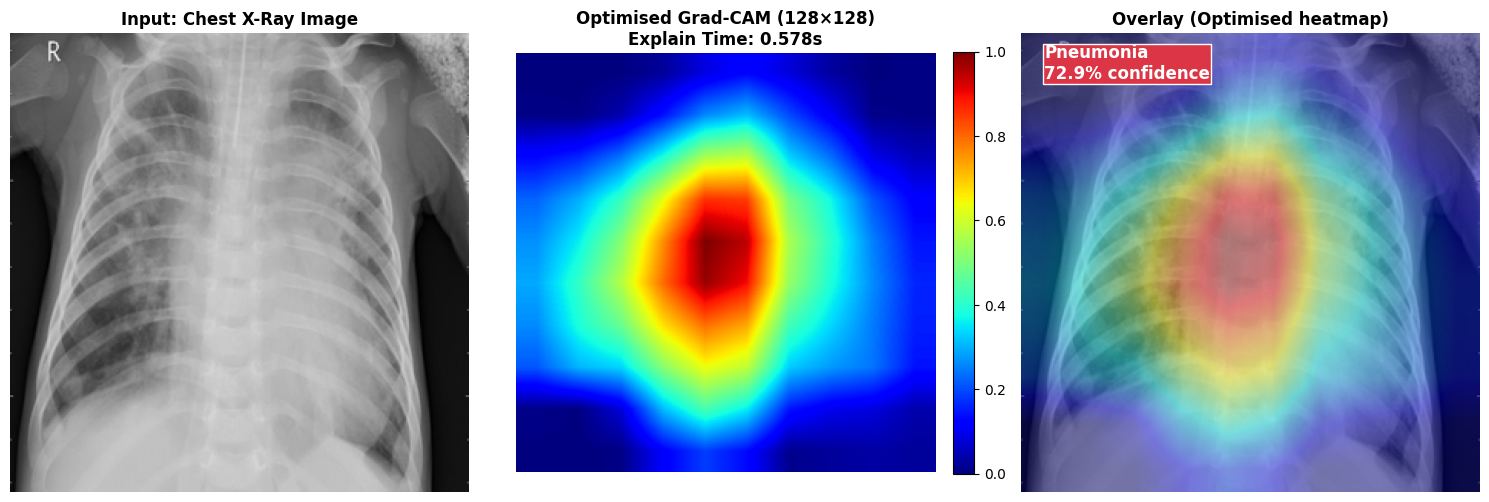


=== Grad-CAM Performance Summary (Xception) ===
Optimized Grad-CAM time: 577.53 ms
Model size: 21.61 MB
Final diagnosis: Pneumonia (72.9% confidence)


In [59]:
# Initialise Grad-CAM with the full Xception model
H5_MODEL_PATH = '/content/drive/MyDrive/chest_xray/base_model_3.keras'
gradcam = OptimisedClinicalGradCAM(
    h5_path=H5_MODEL_PATH,
    gradcam_size=(128, 128),
    target_size=(299, 299),  # Xception input size
    clock_factor=clock_factor
)

# Prepare image for Grad-CAM analysis
img_keras, img_display = gradcam.prepare_image(test_img_path)

# Generate optimized Grad-CAM explanation
heat_opt, preds_opt, gradcam_time = gradcam.generate_optimised_gradcam(img_keras)

# Extract diagnosis and confidence
if gradcam.model_type == "softmax":
    # Two-class output [normal, pneumonia]
    softmax_probs = tf.nn.softmax(tf.expand_dims(preds_opt, 0))[0]
    norm_prob = float(softmax_probs[0])
    pneu_prob = float(softmax_probs[1])
else:
    # Single sigmoid output
    pneu_prob = float(preds_opt)
    norm_prob = 1.0 - pneu_prob

diagnosis = "Pneumonia" if pneu_prob > 0.5 else "Normal"
confidence = (pneu_prob if diagnosis == "Pneumonia" else norm_prob) * 100.0

# Create overlay visualization
overlay = gradcam.create_overlay(img_display, heat_opt)

# Create comprehensive visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Original X-ray
axes[0].imshow(img_display, cmap='gray')
axes[0].set_title("Input: Chest X-Ray Image", fontweight='bold')
axes[0].axis('off')

# Panel 2: Grad-CAM heatmap with timing info
ax1 = axes[1].imshow(heat_opt, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Optimised Grad-CAM (128×128)\nExplain Time: {gradcam_time:.3f}s", fontweight='bold')
axes[1].axis('off')
plt.colorbar(ax1, ax=axes[1], fraction=0.046, pad=0.04)

# Panel 3: Overlay with diagnosis
axes[2].imshow(overlay)
axes[2].set_title("Overlay (Optimised heatmap)", fontweight='bold')
axes[2].axis('off')

# Add diagnosis annotation
text_color = '#dc3545' if diagnosis == "Pneumonia" else '#28a745'
axes[2].text(0.05, 0.90, f"{diagnosis}\n{confidence:.1f}% confidence",
             transform=axes[2].transAxes, color='white', fontsize=12, fontweight='bold',
             bbox=dict(facecolor=text_color, edgecolor='white', pad=0.5))

plt.tight_layout()
plt.show()

# Final performance summary
print("\n=== Grad-CAM Performance Summary (Xception) ===")
print(f"Optimized Grad-CAM time: {gradcam_time*1000:.2f} ms")
print(f"Model size: {model_size_mb:.2f} MB")
print(f"Final diagnosis: {diagnosis} ({confidence:.1f}% confidence)")

#### **Visualisation & Combined Results (Inference & Optimised Grad-CAM Explanation Time)**

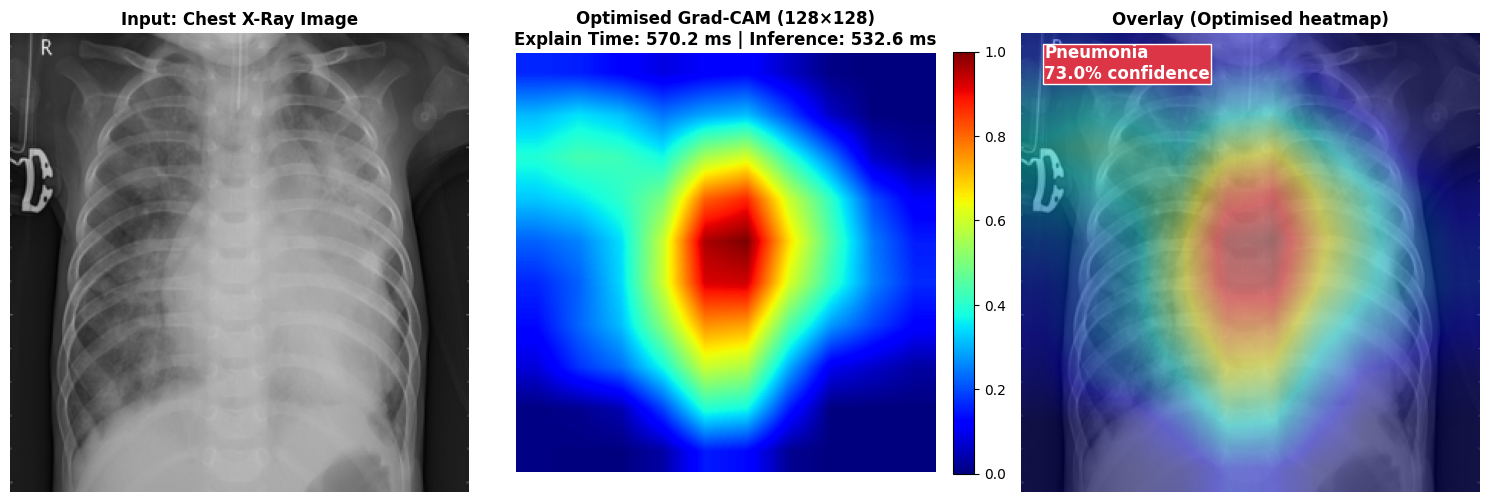

=== Final Combined Results (Xception) ===
Inference time: 532.59 ms
Optimised Grad-CAM time: 570.21 ms
Final diagnosis: Pneumonia (73.0% confidence)


In [60]:
# Load TFLite quantized Xception model
quantized_model_path = '/content/drive/MyDrive/chest_xray/PTQ_Quantized_Ensemble/base_model_3_int8.tflite'
interpreter = tf.lite.Interpreter(quantized_model_path)
input_details = interpreter.get_input_details()
interpreter.resize_tensor_input(input_details[0]['index'], [1, 299, 299, 3])
interpreter.allocate_tensors()

# Preprocessing for Xception
def prepare_image_tflite(path):
    img = Image.open(path).convert('RGB').resize((299, 299))
    arr = np.array(img, dtype=np.float32)
    arr = preprocess_input(arr.copy())
    return np.expand_dims(arr, 0)

# Load and preprocess the test image
test_img_path = '/content/drive/MyDrive/chest_xray/test/PNEUMONIA/BACTERIA-1351146-0001.jpeg'
input_data = prepare_image_tflite(test_img_path)

# Warm-up run
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Measure inference time
start = time.perf_counter()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
duration_ms = (time.perf_counter() - start) * 1000 * clock_factor

# Generate Optimised Grad-CAM (reuse the gradcam object from Cell 4)
img_keras, img_display = gradcam.prepare_image(test_img_path)
heat_opt, preds_opt, t_opt = gradcam.generate_optimised_gradcam(img_keras)

# Determine diagnosis and confidence (same logic as above)
if gradcam.model_type == "softmax":
    norm_prob = float(tf.nn.softmax(tf.expand_dims(preds_opt,0))[0,0])
    pneu_prob = float(tf.nn.softmax(tf.expand_dims(preds_opt,0))[0,1])
else:
    pneu_prob = float(preds_opt)
    norm_prob = 1.0 - pneu_prob

diagnosis = "Pneumonia" if pneu_prob > 0.5 else "Normal"
confidence = (pneu_prob if diagnosis=="Pneumonia" else norm_prob) * 100.0
text_color = '#dc3545' if diagnosis == "Pneumonia" else '#28a745'
overlay = gradcam.create_overlay(img_display, heat_opt)

# Plot 3 panels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Original X-ray
axes[0].imshow(img_display, cmap='gray')
axes[0].set_title("Input: Chest X-Ray Image", fontweight='bold')
axes[0].axis('off')

# Panel 2: Grad-CAM heatmap with timing
ax1 = axes[1].imshow(heat_opt, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Optimised Grad-CAM (128×128)\nExplain Time: {t_opt*1000:.1f} ms | Inference: {duration_ms:.1f} ms", fontweight='bold')
axes[1].axis('off')
plt.colorbar(ax1, ax=axes[1], fraction=0.046, pad=0.04)

# Panel 3: Overlay with diagnosis
axes[2].imshow(overlay)
axes[2].set_title("Overlay (Optimised heatmap)", fontweight='bold')
axes[2].axis('off')
axes[2].text(0.05, 0.90, f"{diagnosis}\n{confidence:.1f}% confidence",
             transform=axes[2].transAxes, color='white', fontsize=12, fontweight='bold',
             bbox=dict(facecolor=text_color, edgecolor='white', pad=0.5))

plt.tight_layout()
plt.show()

# Print timing results
print("=== Final Combined Results (Xception) ===")
print(f"Inference time: {duration_ms:.2f} ms")
print(f"Optimised Grad-CAM time: {t_opt*1000:.2f} ms")
print(f"Final diagnosis: {diagnosis} ({confidence:.1f}% confidence)")